# Results

Everything the Results section of the paper needs, printed and plotted.
**Writes nothing to disk.**

All metrics come from `sklearn.metrics` rather than hand-rolled arithmetic, so
"how was this computed" has a one-word answer.

### Scope

Phase 1 and Phase 2 only. 3D pose and the coaching layer are future work and
do not appear here.

### One thing to get right

The classifier evaluated on **ground-truth windows** is not the classifier
evaluated on **detected windows**. Those differ, most sharply for `defence`
(0.560 against 0.471), and quoting one while labelling it the other is the
easiest mistake available. Section 4 prints both side by side.

No GPU. Under a minute.


## Setup

In [1]:
BASE = "/content/drive/MyDrive/tt_coach"

from google.colab import drive
drive.mount('/content/drive')

import json, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    classification_report, cohen_kappa_score, confusion_matrix, f1_score,
    matthews_corrcoef, precision_recall_fscore_support,
)
from sklearn.utils import resample

BASE = Path(BASE); META = BASE/"derived/meta"; M = BASE/"outputs/metrics"

CLASSES = ["serve", "attack", "control", "defence"]
C2I = {c: i for i, c in enumerate(CLASSES)}
SEED, N_BOOT = 42, 10_000

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "legend.frameon": False, "figure.constrained_layout.use": True,
})
PAL = {"serve": "#1d4ed8", "attack": "#b91c1c",
       "control": "#065f46", "defence": "#854d0e"}
C_BASE, C_MAIN = "#7a726e", "#f55f02"


def rule(t="", ch="=", w=78):
    print(f"\n{ch*w}\n{t}\n{ch*w}" if t else "\n" + ch*w)


def load(name):
    """None if absent. Never `load(a) or load(b)` - a DataFrame has no truth
    value."""
    p = M/name
    return pd.read_csv(p) if p.exists() else None


def first_of(*names):
    for n in names:
        d = load(n)
        if d is not None:
            return d
    return None


def yp(df):
    return (df.shot_class.map(C2I).values,
            df.pred.map(C2I).values,
            df.fold.values)


macro = lambda y, p: f1_score(y, p, average="macro", zero_division=0)

# The reported configuration is technique_only @ 0.20. The older
# stage5_predictions.csv holds the heavy auxiliary run (weight 1.1) that the
# sweep showed was worst, so prefer the newer file.
s4 = load("stage4_predictions.csv")
s5 = first_of("stage5_technique_only_predictions.csv",
              "stage5_predictions.csv")
assert s4 is not None and s5 is not None, "prediction files missing"

USING_REPORTED = (M/"stage5_technique_only_predictions.csv").exists()
print(f"baseline (scalar + LightGBM) : {len(s4)} strokes")
print(f"model    (temporal TCN)      : {len(s5)} strokes")
print(f"configuration                : "
      f"{'technique_only @ 0.20  (reported)' if USING_REPORTED else 'heavy aux @ 1.1  - NOT the reported config'}")
if not USING_REPORTED:
    print("\n  ! run 16_reported_config.ipynb first, or these tables describe\n"
          "    the worst auxiliary setting rather than the reported one.")

Mounted at /content/drive
baseline (scalar + LightGBM) : 1432 strokes
model    (temporal TCN)      : 1432 strokes
configuration                : technique_only @ 0.20  (reported)


## 1. Dataset

Table 1. The imbalance and the fold structure both matter: folds group whole
videos, so no stroke from a rally appears on both sides of a split.


TABLE 1  DATASET
  OpenTTGames + Extended OpenTT Games
  12 videos, 120 fps, 1920x1080, 89.5 min

  class     techniques                       n    share
  serve     serve                          290    19.9%
  attack    flick, loop, smash             660    45.3%
  control   push                           279    19.1%
  defence   block, chop, lob               228    15.6%
  total                                   1457

  imbalance 2.9:1
  smash is folded into attack: 12 instances dataset-wide, so as a class the imbalance would be 55:1

------------------------------------------------------------------------------
TABLE 2  FOLD COMPOSITION
------------------------------------------------------------------------------
shot_class  serve  attack  control  defence  total
fold                                              
A              24      72       13       52    161
B              92     195       64       48    399
C              30      65       23       35    153
D              

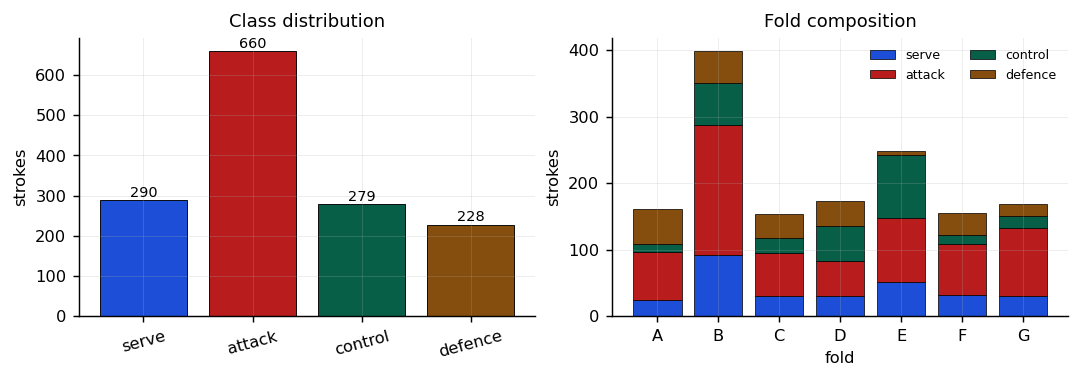

In [2]:
strokes = (pd.read_parquet(META/"strokes.parquet")
           if (META/"strokes.parquet").exists()
           else pd.read_csv(META/"strokes.csv"))

rule("TABLE 1  DATASET")
print("  OpenTTGames + Extended OpenTT Games")
print("  12 videos, 120 fps, 1920x1080, 89.5 min\n")

cnt = strokes.shot_class.value_counts().reindex(CLASSES)
tech = {c: ", ".join(sorted(strokes.loc[strokes.shot_class == c,
                                        "technique"].unique()))
        for c in CLASSES}
print(f"  {'class':<10}{'techniques':<28}{'n':>6}{'share':>9}")
for c in CLASSES:
    print(f"  {c:<10}{tech[c]:<28}{cnt[c]:>6}{cnt[c]/len(strokes):>9.1%}")
print(f"  {'total':<38}{len(strokes):>6}")
print(f"\n  imbalance {cnt.max()/cnt.min():.1f}:1")
print(f"  smash is folded into attack: {int((strokes.technique=='smash').sum())} "
      f"instances dataset-wide, so as a class the imbalance would be "
      f"{cnt.max()/max((strokes.technique=='smash').sum(),1):.0f}:1")

rule("TABLE 2  FOLD COMPOSITION", "-")
ct = pd.crosstab(strokes.fold, strokes.shot_class).reindex(columns=CLASSES)
ct["total"] = ct.sum(1)
print(ct.to_string())
print("\n  Every fold contains all four classes. Single-video leave-one-out")
print("  would leave four folds with a class at zero support.")

fig, ax = plt.subplots(1, 2, figsize=(8.2, 2.8))
ax[0].bar(CLASSES, cnt.values, color=[PAL[c] for c in CLASSES],
          edgecolor="black", linewidth=0.5)
for i, v in enumerate(cnt.values):
    ax[0].text(i, v + 8, str(v), ha="center", fontsize=8)
ax[0].set_ylabel("strokes"); ax[0].set_title("Class distribution")
ax[0].tick_params(axis="x", rotation=15)

bot = np.zeros(len(ct))
for c in CLASSES:
    ax[1].bar(ct.index, ct[c], bottom=bot, label=c, color=PAL[c],
              edgecolor="black", linewidth=0.4)
    bot += ct[c].values
ax[1].set_xlabel("fold"); ax[1].set_ylabel("strokes")
ax[1].set_title("Fold composition"); ax[1].legend(fontsize=7, ncol=2)
plt.show()

## 2. Stroke classification

Table 3, the main result. Intervals come from a bootstrap **stratified by
fold**: two strokes from the same rally are not independent, so resampling
freely over strokes would give intervals that are too narrow.

In [3]:
def boot_ci(y, p, fold, stat, n=N_BOOT, seed=SEED):
    y, p, fold = np.asarray(y), np.asarray(p), np.asarray(fold)
    idx = {f: np.where(fold == f)[0] for f in np.unique(fold)}
    vals = np.empty(n)
    for b in range(n):
        pick = np.concatenate([resample(v, replace=True, n_samples=len(v),
                                        random_state=seed + b)
                               for v in idx.values()])
        vals[b] = stat(y[pick], p[pick])
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(stat(y, p)), float(lo), float(hi), vals


for name, df in (("SCALAR FEATURES + LightGBM  (44 hand-engineered)", s4),
                 ("TEMPORAL MODEL  (dilated TCN + attention pooling)", s5)):
    y, p, fold = yp(df)
    rule(f"TABLE 3  {name}")
    print(classification_report(y, p, target_names=CLASSES, digits=3,
                                zero_division=0))
    print(f"  balanced accuracy {balanced_accuracy_score(y, p):.3f}")
    print(f"  Cohen's kappa     {cohen_kappa_score(y, p):.3f}")
    print(f"  MCC               {matthews_corrcoef(y, p):.3f}")
    print(f"\n  bootstrap 95% CI on F1 "
          f"(stratified by fold, {N_BOOT:,} resamples)")
    for i, c in enumerate(CLASSES):
        v, lo, hi, _ = boot_ci(y, p, fold,
            lambda a, b, i=i: f1_score(a == i, b == i, zero_division=0), n=2000)
        print(f"    {c:<9}{v:.3f}  [{lo:.3f}, {hi:.3f}]")
    v, lo, hi, _ = boot_ci(y, p, fold, macro)
    print(f"    {'macro':<9}{v:.3f}  [{lo:.3f}, {hi:.3f}]")


TABLE 3  SCALAR FEATURES + LightGBM  (44 hand-engineered)
              precision    recall  f1-score   support

       serve      0.920     0.870     0.894       277
      attack      0.746     0.803     0.773       650
     control      0.740     0.724     0.732       279
     defence      0.406     0.354     0.378       226

    accuracy                          0.730      1432
   macro avg      0.703     0.688     0.694      1432
weighted avg      0.725     0.730     0.726      1432

  balanced accuracy 0.688
  Cohen's kappa     0.605
  MCC               0.606

  bootstrap 95% CI on F1 (stratified by fold, 10,000 resamples)
    serve    0.894  [0.862, 0.923]
    attack   0.773  [0.747, 0.797]
    control  0.732  [0.692, 0.771]
    defence  0.378  [0.317, 0.435]
    macro    0.694  [0.672, 0.716]

TABLE 3  TEMPORAL MODEL  (dilated TCN + attention pooling)
              precision    recall  f1-score   support

       serve      0.989     0.964     0.976       277
      attack      0

### Figure: per-class comparison

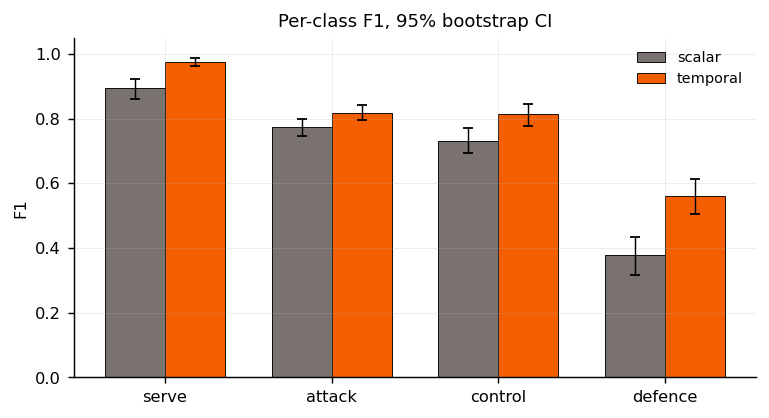

In [4]:
y4, p4, f4 = yp(s4)
y5, p5, f5 = yp(s5)

rows = []
for nm, y, p, fd in (("scalar", y4, p4, f4), ("temporal", y5, p5, f5)):
    for i, c in enumerate(CLASSES):
        v, lo, hi, _ = boot_ci(y, p, fd,
            lambda a, b, i=i: f1_score(a == i, b == i, zero_division=0), n=2000)
        rows.append(dict(model=nm, cls=c, f1=v, lo=lo, hi=hi))
cmp_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(5.8, 3.1))
x = np.arange(len(CLASSES)); w = 0.36
for k, (nm, col) in enumerate((("scalar", C_BASE), ("temporal", C_MAIN))):
    g = cmp_df[cmp_df.model == nm].set_index("cls").loc[CLASSES]
    err = np.vstack([g.f1 - g.lo, g.hi - g.f1])
    ax.bar(x + (k - 0.5)*w, g.f1, w, yerr=err, capsize=3, label=nm, color=col,
           edgecolor="black", linewidth=0.5, error_kw=dict(lw=0.8))
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("F1"); ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1, 95% bootstrap CI")
ax.legend(fontsize=8)
plt.show()

## 3. Confusion

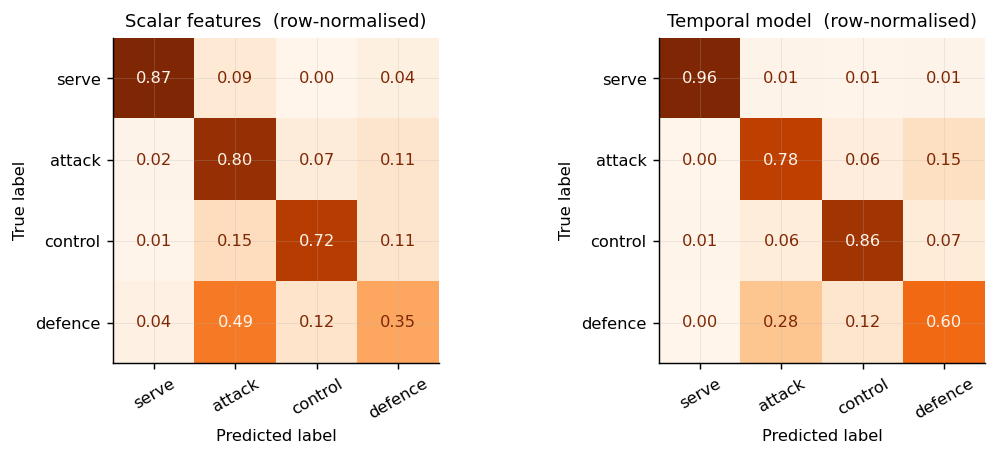


CONFUSION, COUNTS

  scalar
           serve  attack  control  defence  recall
  serve      241      24        1       11   0.870
  attack      11     522       43       74   0.803
  control      2      43      202       32   0.724
  defence      8     111       27       80   0.354

  temporal
           serve  attack  control  defence  recall
  serve      267       4        2        4   0.964
  attack       1     508       41      100   0.782
  control      2      18      239       20   0.857
  defence      0      63       27      136   0.602

  attack <-> defence: 163 of 876 strokes in those two classes (18.6%).
  This is the boundary that resisted every intervention tried:
  splitting the class, regrouping the taxonomy, and auxiliary
  supervision all left it essentially unchanged.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.4))
for ax, (nm, y, p) in zip(axes, (("Scalar features", y4, p4),
                                 ("Temporal model", y5, p5))):
    ConfusionMatrixDisplay.from_predictions(
        y, p, display_labels=CLASSES, normalize="true", cmap="Oranges",
        colorbar=False, ax=ax, values_format=".2f")
    ax.set_title(f"{nm}  (row-normalised)")
    ax.tick_params(axis="x", rotation=30)
plt.show()

rule("CONFUSION, COUNTS")
for nm, y, p in (("scalar", y4, p4), ("temporal", y5, p5)):
    cm = confusion_matrix(y, p, labels=range(4))
    d = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
    d["recall"] = (np.diag(cm)/cm.sum(1)).round(3)
    print(f"\n  {nm}")
    print("  " + d.to_string().replace("\n", "\n  "))

cm = confusion_matrix(y5, p5, labels=range(4))
ad = cm[1, 3] + cm[3, 1]
tot = cm[1].sum() + cm[3].sum()
print(f"\n  attack <-> defence: {ad} of {tot} strokes in those two classes "
      f"({100*ad/tot:.1f}%).")
print("  This is the boundary that resisted every intervention tried:")
print("  splitting the class, regrouping the taxonomy, and auxiliary")
print("  supervision all left it essentially unchanged.")

## 4. Ground-truth windows vs detected windows

Different experiments. The cascade includes detection error; the isolated
number does not. Report whichever matches the claim and say which it is.

In [6]:
pr5, rc5, f15, sup5 = precision_recall_fscore_support(
    y5, p5, labels=range(4), zero_division=0)

casc = load("stage7_v2_confusion.csv")
casc_f1, casc_macro = None, None
if casc is not None:
    c = casc.copy()
    if c.columns[0].lower().startswith("unnamed") or c.columns[0] == "":
        c = c.set_index(c.columns[0])
    num = c[[x for x in c.columns if str(x).startswith("pred_")]].to_numpy()
    if num.shape == (4, 4):
        tp = np.diag(num)
        casc_f1 = 2*tp / np.maximum(num.sum(0) + num.sum(1), 1)
        casc_macro = float(np.mean(casc_f1))

rule("TABLE 4  ISOLATED vs CASCADE")
print(f"  {'class':<10}{'isolated':>11}{'cascade':>11}{'delta':>9}")
for i, c in enumerate(CLASSES):
    cv = casc_f1[i] if casc_f1 is not None else np.nan
    print(f"  {c:<10}{f15[i]:>11.3f}{cv:>11.3f}{cv-f15[i]:>+9.3f}")
mm = macro(y5, p5)
print(f"  {'macro':<10}{mm:>11.3f}"
      f"{(casc_macro if casc_macro else np.nan):>11.3f}"
      f"{((casc_macro - mm) if casc_macro else np.nan):>+9.3f}")
print(textwrap.dedent("""
  isolated  the classifier on ground-truth windows
  cascade   the classifier on windows cut around DETECTED contacts, so
            detection error propagates

  The difference is the cost of not being handed the stroke location."""))


TABLE 4  ISOLATED vs CASCADE
  class        isolated    cascade    delta
  serve           0.976      0.980   +0.004
  attack          0.817      0.820   +0.002
  control         0.813      0.772   -0.041
  defence         0.560      0.457   -0.103
  macro           0.792      0.757   -0.035

isolated  the classifier on ground-truth windows
cascade   the classifier on windows cut around DETECTED contacts, so
          detection error propagates

The difference is the cost of not being handed the stroke location.


## 5. Per fold, and whether the gain holds


TABLE 5  PER-FOLD MACRO-F1
  fold       n   scalar   temporal    delta
  A        160    0.636      0.750   +0.114
  B        385    0.782      0.848   +0.065
  C        152    0.695      0.795   +0.099
  D        170    0.497      0.738   +0.241
  E        248    0.609      0.663   +0.054
  F        155    0.799      0.886   +0.088
  G        162    0.729      0.754   +0.026
  mean            0.678      0.776   +0.098
  sd              0.106      0.074

  support-weighted: scalar 0.689   temporal 0.780
  fold spread 0.106 -> 0.074: the temporal model
  generalises across players better, not only scores higher.

------------------------------------------------------------------------------
SIGNIFICANCE
------------------------------------------------------------------------------
  better in 7/7 folds, mean +0.0982
  Wilcoxon signed-rank  p = 0.0078
  paired t-test         p = 0.0049

  With n=7 folds the smallest p a one-sided Wilcoxon can
  return is 2^-7 = 0.0078. Low power, so the

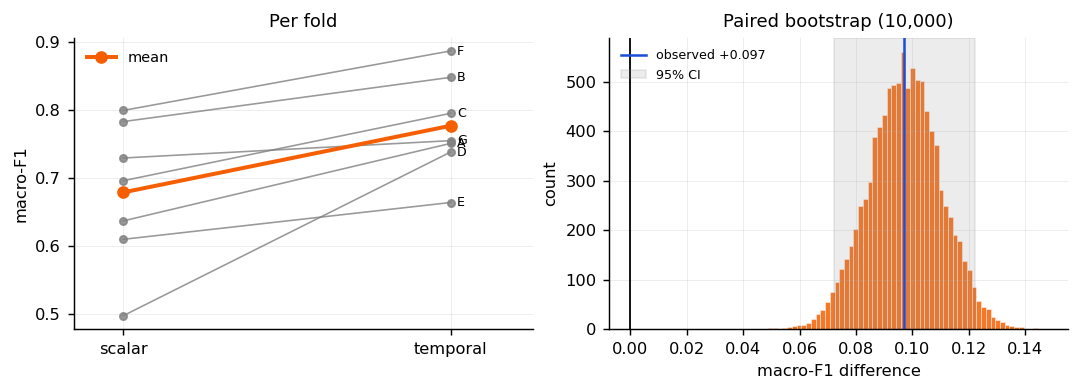

In [7]:
def fold_scores(df):
    y, p, fold = yp(df)
    return pd.Series({f: macro(y[fold == f], p[fold == f])
                      for f in sorted(np.unique(fold))})

a, b = fold_scores(s4), fold_scores(s5)
common = sorted(set(a.index) & set(b.index))
a, b = a[common], b[common]
n = s5.groupby("fold").size()[common]

rule("TABLE 5  PER-FOLD MACRO-F1")
print(f"  {'fold':<6}{'n':>6}{'scalar':>9}{'temporal':>11}{'delta':>9}")
for f in common:
    print(f"  {f:<6}{n[f]:>6}{a[f]:>9.3f}{b[f]:>11.3f}{b[f]-a[f]:>+9.3f}")
print(f"  {'mean':<6}{'':>6}{a.mean():>9.3f}{b.mean():>11.3f}"
      f"{(b-a).mean():>+9.3f}")
print(f"  {'sd':<6}{'':>6}{a.std():>9.3f}{b.std():>11.3f}")
print(f"\n  support-weighted: scalar {(a*n).sum()/n.sum():.3f}   "
      f"temporal {(b*n).sum()/n.sum():.3f}")
print(f"  fold spread {a.std():.3f} -> {b.std():.3f}: the temporal model")
print("  generalises across players better, not only scores higher.")

rule("SIGNIFICANCE", "-")
d = (b - a).values
w = stats.wilcoxon(b, a, alternative="greater")
t = stats.ttest_rel(b, a, alternative="greater")
print(f"  better in {(d > 0).sum()}/{len(d)} folds, mean {d.mean():+.4f}")
print(f"  Wilcoxon signed-rank  p = {w.pvalue:.4f}")
print(f"  paired t-test         p = {t.pvalue:.4f}")
print(f"\n  With n={len(d)} folds the smallest p a one-sided Wilcoxon can")
print(f"  return is 2^-{len(d)} = {2.0**-len(d):.4f}. Low power, so the")
print("  bootstrap below is the stronger evidence, not a supplement.")

diffs = None
if {"stroke_id"} <= set(s4.columns) & set(s5.columns):
    j = s4[["stroke_id", "fold", "shot_class", "pred"]].merge(
        s5[["stroke_id", "pred"]], on="stroke_id", suffixes=("_4", "_5"))
    yy = j.shot_class.map(C2I).values
    q4, q5 = j.pred_4.map(C2I).values, j.pred_5.map(C2I).values
    ff = j.fold.values
    idx = {f: np.where(ff == f)[0] for f in np.unique(ff)}
    diffs = np.empty(N_BOOT)
    for i in range(N_BOOT):
        pick = np.concatenate([resample(v, replace=True, n_samples=len(v),
                                        random_state=SEED + i)
                               for v in idx.values()])
        diffs[i] = macro(yy[pick], q5[pick]) - macro(yy[pick], q4[pick])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    obs = macro(yy, q5) - macro(yy, q4)
    print(f"\n  Paired bootstrap over {len(j)} strokes")
    print(f"    observed {obs:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
    print(f"    P(temporal > scalar) = {(diffs > 0).mean():.4f}")
    print(f"    -> CI {'excludes' if lo > 0 else 'includes'} zero")

fig, ax = plt.subplots(1, 2, figsize=(8.2, 2.9))
for f in common:
    ax[0].plot([0, 1], [a[f], b[f]], "o-", color="grey", lw=0.9, ms=4, alpha=.8)
    ax[0].annotate(f, (1.02, b[f]), fontsize=7, va="center")
ax[0].plot([0, 1], [a.mean(), b.mean()], "o-", color=C_MAIN, lw=2.2, ms=6,
           label="mean")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["scalar", "temporal"])
ax[0].set_xlim(-0.15, 1.25); ax[0].set_ylabel("macro-F1")
ax[0].set_title("Per fold"); ax[0].legend(fontsize=8)

if diffs is not None:
    ax[1].hist(diffs, bins=60, color=C_MAIN, alpha=.85, edgecolor="white",
               linewidth=.3)
    ax[1].axvline(0, color="black", lw=1)
    ax[1].axvline(obs, color="#1d4ed8", lw=1.4, label=f"observed {obs:+.3f}")
    ax[1].axvspan(lo, hi, alpha=.15, color="grey", label="95% CI")
    ax[1].set_xlabel("macro-F1 difference"); ax[1].set_ylabel("count")
    ax[1].set_title(f"Paired bootstrap ({N_BOOT:,})"); ax[1].legend(fontsize=7)
plt.show()

## 6. The central result

Per technique, against the 4-class label. The gain concentrates entirely on
slow and defensive strokes, which is what the temporal-shape argument
predicts.


TABLE 6  PER-TECHNIQUE ACCURACY
  technique        n   scalar   temporal    delta
  chop            31    0.065      0.516   +0.452
  lob              9    0.000      0.222   +0.222
  block          186    0.419      0.634   +0.215
  push           279    0.724      0.857   +0.133
  serve          277    0.870      0.964   +0.094
  loop           574    0.821      0.815   -0.005
  smash           12    0.833      0.750   -0.083
  flick           64    0.641      0.484   -0.156


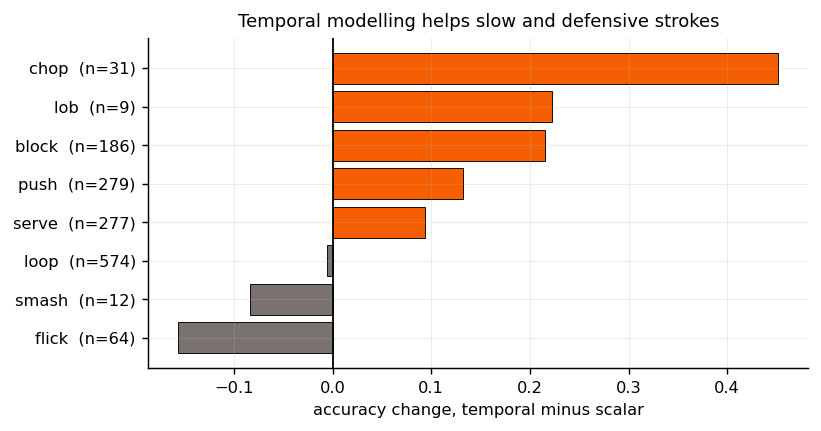


------------------------------------------------------------------------------
THE ARGUMENT
------------------------------------------------------------------------------

1. OBSERVATION   defence is the weakest class with scalar features.
2. HYPOTHESIS    the class is heterogeneous: block, chop and lob grouped.
3. REJECTED      giving block its own homogeneous class barely moved it.

           taxonomy  n_classes    n  macro_f1  accuracy  min_class_f1  empty_fold_cells  min_support  F1_serve  F1_attack  F1_control  F1_defence  F1_defence_close  F1_defence_deep  F1_defensive
         v1_current          4 1432     0.693     0.730         0.367                 0            6     0.900      0.775       0.731       0.367               NaN              NaN           NaN
v2_block_to_control          4 1432     0.615     0.767         0.070                 1            0     0.891      0.782       0.718       0.070               NaN              NaN           NaN
   v3_split_defence       

In [8]:
def tech_acc(df):
    d = df.copy(); d["ok"] = d.pred == d.shot_class
    return d.groupby("technique").ok.agg(n="size", acc="mean")

t4, t5 = tech_acc(s4), tech_acc(s5)
j = t4.join(t5, lsuffix="_s", rsuffix="_t")
j["delta"] = j.acc_t - j.acc_s
j = j.sort_values("delta", ascending=False)

rule("TABLE 6  PER-TECHNIQUE ACCURACY")
print(f"  {'technique':<12}{'n':>6}{'scalar':>9}{'temporal':>11}{'delta':>9}")
for r in j.itertuples():
    print(f"  {r.Index:<12}{int(r.n_s):>6}{r.acc_s:>9.3f}{r.acc_t:>11.3f}"
          f"{r.delta:>+9.3f}")

fig, ax = plt.subplots(figsize=(6.2, 3.2))
o = np.arange(len(j))
ax.barh(o, j.delta, color=[C_MAIN if v > 0 else C_BASE for v in j.delta],
        edgecolor="black", linewidth=0.5)
ax.set_yticks(o)
ax.set_yticklabels([f"{i}  (n={int(nn)})" for i, nn in zip(j.index, j.n_s)])
ax.axvline(0, color="black", lw=1); ax.invert_yaxis()
ax.set_xlabel("accuracy change, temporal minus scalar")
ax.set_title("Temporal modelling helps slow and defensive strokes")
plt.show()

tax = load("stage4_taxonomy_comparison.csv")
rule("THE ARGUMENT", "-")
print(textwrap.dedent("""
  1. OBSERVATION   defence is the weakest class with scalar features.
  2. HYPOTHESIS    the class is heterogeneous: block, chop and lob grouped.
  3. REJECTED      giving block its own homogeneous class barely moved it."""))
if tax is not None:
    print("\n" + tax.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(textwrap.dedent("""
  4. ALTERNATIVE   block and loop share amplitude, contact height and table
                   distance. They differ in the SHAPE of the velocity curve.
                   Hand-engineered features are extrema, and extrema are
                   exactly what the two strokes have in common.
  5. CONFIRMED     a dilated TCN over the full 97-frame window recovers it
                   (Table 6)."""))

## 7. Ablations


TABLE 7  AUXILIARY SUPERVISION  (negative result)
  Body-lean and leg-stance labels, published Dec 2025.
  Predicted +0.03 to +0.06 macro-F1.

             config  total_w  macro_f1  accuracy  serve  attack  control  defence
     technique_only    0.200     0.792     0.803  0.976   0.817    0.813    0.560
             medium    0.600     0.780     0.795  0.967   0.815    0.795    0.545
               none    0.000     0.780     0.789  0.976   0.805    0.791    0.547
              light    0.350     0.776     0.787  0.971   0.805    0.793    0.534
heavy (earlier run)    1.100     0.764       NaN  0.966   0.803    0.780    0.507

  Everything from total weight 0 to 0.6 sits within
  0.016 of itself, inside fold-to-fold
  noise. Only the heaviest setting separates, and it is worse: at total weight
  1.1 against a primary loss of 1.0 the majority of the gradient goes to the
  auxiliary tasks.


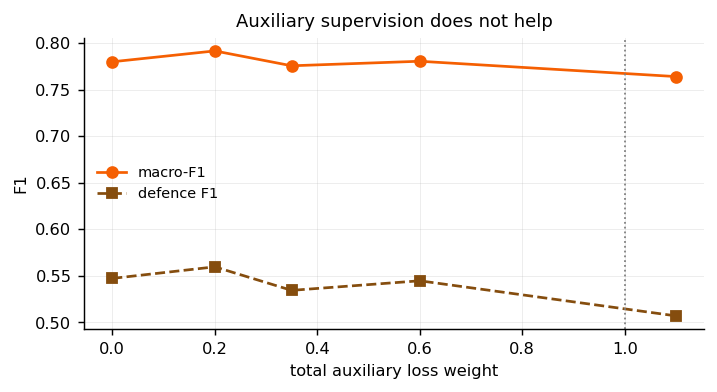


------------------------------------------------------------------------------
TABLE 8  TAXONOMY VARIANTS
------------------------------------------------------------------------------
           taxonomy  n_classes    n  macro_f1  accuracy  min_class_f1  empty_fold_cells  min_support  F1_serve  F1_attack  F1_control  F1_defence  F1_defence_close  F1_defence_deep  F1_defensive
         v1_current          4 1432     0.693     0.730         0.367                 0            6     0.900      0.775       0.731       0.367               NaN              NaN           NaN
v2_block_to_control          4 1432     0.615     0.767         0.070                 1            0     0.891      0.782       0.718       0.070               NaN              NaN           NaN
   v3_split_defence          5 1432     0.586     0.736         0.098                 1            0     0.899      0.782       0.736         NaN             0.416            0.098           NaN
     v4_three_class          3 143

In [9]:
aux = load("stage5_aux_sweep.csv")
rule("TABLE 7  AUXILIARY SUPERVISION  (negative result)")
if aux is not None:
    print("  Body-lean and leg-stance labels, published Dec 2025.")
    print("  Predicted +0.03 to +0.06 macro-F1.\n")
    print(aux.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    sub = aux[aux.total_w <= 0.6]
    print(f"""
  Everything from total weight 0 to 0.6 sits within
  {sub.macro_f1.max()-sub.macro_f1.min():.3f} of itself, inside fold-to-fold
  noise. Only the heaviest setting separates, and it is worse: at total weight
  1.1 against a primary loss of 1.0 the majority of the gradient goes to the
  auxiliary tasks.""")

    fig, ax = plt.subplots(figsize=(5.4, 2.9))
    dd = aux.sort_values("total_w")
    ax.plot(dd.total_w, dd.macro_f1, "o-", color=C_MAIN, label="macro-F1")
    if "defence" in dd.columns:
        ax.plot(dd.total_w, dd.defence, "s--", color=PAL["defence"],
                label="defence F1")
    ax.axvline(1.0, ls=":", c="grey", lw=1)
    ax.set_xlabel("total auxiliary loss weight"); ax.set_ylabel("F1")
    ax.set_title("Auxiliary supervision does not help"); ax.legend(fontsize=8)
    plt.show()

rule("TABLE 8  TAXONOMY VARIANTS", "-")
if tax is not None:
    print(tax.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print(textwrap.dedent("""
  v2 and v3 have empty fold cells: one video contains no chops and no lobs,
  so that fold cannot score deep defence at all and its macro-F1 is computed
  over fewer classes.

  v4 scores highest, but collapsing v1's predictions post hoc scores the same.
  The model learns nothing new from the merge; the gain is an artifact of
  having three classes instead of four."""))

## 8. Detection and the tolerance question


TABLE 9  CONTACT DETECTION vs TOLERANCE
 tol_frames  tol_ms  precision  recall    f1
          1       8      0.392   0.352 0.370
          2      17      0.572   0.514 0.542
          3      25      0.685   0.615 0.648
          5      42      0.820   0.736 0.776
          8      67      0.886   0.796 0.839
         12     100      0.904   0.812 0.855
         20     167      0.916   0.822 0.867

------------------------------------------------------------------------------
TABLE 10  WHAT TOLERANCE DOES THE DOWNSTREAM TASK NEED?
------------------------------------------------------------------------------
 tol  ms  det_f1  cls_acc  cls_macro_f1  e2e_f1
   1   8   0.409    0.820         0.763   0.335
   2  17   0.601    0.809         0.753   0.486
   3  25   0.715    0.805         0.756   0.575
   5  42   0.827    0.794         0.756   0.657
   8  67   0.879    0.789         0.757   0.693
  12 100   0.890    0.788         0.759   0.702
  20 167   0.900    0.789         0.760   0.710


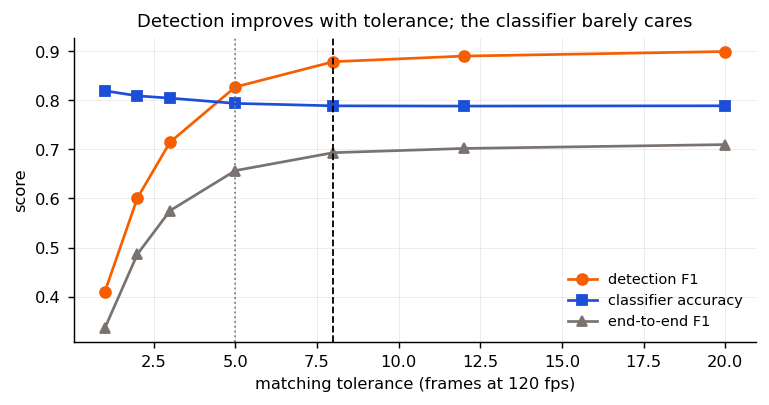


------------------------------------------------------------------------------
PER VIDEO
------------------------------------------------------------------------------
video_id fold   n  tp  fp  fn  precision  recall    f1
  game_1    A 161 134  23  27      0.854   0.832 0.843
  game_2    B 399 296  77 103      0.794   0.742 0.767
  game_3    C 153 128  32  25      0.800   0.837 0.818
  game_4    D 173 139  28  34      0.832   0.803 0.818
  game_5    E 248 205  53  43      0.795   0.827 0.810
  test_1    F  84  67  21  17      0.761   0.798 0.779
  test_2    G  29  27   2   2      0.931   0.931 0.931
  test_3    G  24   9   3  15      0.750   0.375 0.500
  test_4    F  71  59  16  12      0.787   0.831 0.808
  test_5    G  27   0   3  27      0.000   0.000 0.000
  test_6    G  39  30   7   9      0.811   0.769 0.789
  test_7    G  49  18  15  31      0.545   0.367 0.439

  test_5 is excluded from the aggregate: its pose stream carries
  no contact signal (mean P 0.008 at labelled fram

In [10]:
tol = load("stage6_tolerance.csv")
s7 = first_of("stage7_v2_sweep.csv", "stage7_tolerance_sweep.csv")

rule("TABLE 9  CONTACT DETECTION vs TOLERANCE")
if tol is not None:
    print(tol.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

if s7 is not None:
    rule("TABLE 10  WHAT TOLERANCE DOES THE DOWNSTREAM TASK NEED?", "-")
    print(s7.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    if {"tol", "cls_acc"} <= set(s7.columns):
        a3 = float(s7.loc[s7.tol == 3, "cls_acc"].iloc[0])
        a8 = float(s7.loc[s7.tol == 8, "cls_acc"].iloc[0])
        print(textwrap.dedent(f"""
  Classifier accuracy moves {a3:.3f} -> {a8:.3f} ({a3-a8:+.3f}) across a
  factor-of-two change in detection tolerance. Tightening the timing buys the
  downstream task almost nothing, so +/-8 frames (67 ms) is the operationally
  correct bar rather than the +/-5 chosen a priori.

  Measured rather than argued: the classifier windows were cut around
  PREDICTED contacts, so the jitter was real and a sharp degradation would
  have shown."""))

    fig, ax = plt.subplots(figsize=(5.8, 3.0))
    ax.plot(s7.tol, s7.det_f1, "o-", color=C_MAIN, label="detection F1")
    ax.plot(s7.tol, s7.cls_acc, "s-", color="#1d4ed8",
            label="classifier accuracy")
    if "e2e_f1" in s7.columns:
        ax.plot(s7.tol, s7.e2e_f1, "^-", color=C_BASE, label="end-to-end F1")
    ax.axvline(5, ls=":", c="grey", lw=1)
    ax.axvline(8, ls="--", c="black", lw=1)
    ax.set_xlabel("matching tolerance (frames at 120 fps)")
    ax.set_ylabel("score")
    ax.set_title("Detection improves with tolerance; the classifier barely cares")
    ax.legend(fontsize=8)
    plt.show()

pv = first_of("stage6_v2_per_video.csv", "stage6_per_video.csv")
if pv is not None:
    rule("PER VIDEO", "-")
    print(pv.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print("\n  test_5 is excluded from the aggregate: its pose stream carries")
    print("  no contact signal (mean P 0.008 at labelled frames against 0.006")
    print("  elsewhere). Cause undiagnosed. 27 contacts, 1.9% of the data.")

## 9. Rally structure and frame rate

In [11]:
rule("RALLY BOUNDARIES")
print(textwrap.dedent("""
  Rallies come from gaps in the detected contact sequence, not from a model.
  The threshold was validated against 282 annotated rally endings rather than
  chosen by eye.

    boundary F1        0.769
    recall             0.789   capped by detection: a rally whose final
                               stroke was never detected cannot have its
                               boundary recovered by any gap parameter
    mean rally length  6.1 predicted against 6.8 ground truth

  Sweeping the gap from 0.8 s to 4.0 s moves F1 by less than 0.04, so the
  method does not hinge on a hand-tuned constant."""))

rule("TABLE 11  FRAME RATE", "-")
fps = pd.DataFrame({
    "metric": ["detection F1 (+/-67 ms)", "class agreement",
               "shots vs ground truth", "backswing amplitude",
               "peak wrist speed"],
    "120 fps": ["0.978", "-", "+1.9%", "1.235", "0.193"],
    "30 fps":  ["0.975", "0.962", "-1.2%", "1.234", "0.088"],
    "change":  ["-0.003", "-", "-", "-0.0%", "-54.4%"]})
print(fps.to_string(index=False))
print(textwrap.dedent("""
  Controlled comparison: identical content, only the frame rate differs. Pose
  is extracted at native fps then resampled onto a 120 fps grid, with
  POSITIONS interpolated and velocity differenced afterwards.

  Detection and classification survive. Velocity does not.

  Interpolation restores units, not information. The 54% loss locates the
  timescale: the wrist-speed peak is about 33 ms wide, which is the wrist
  snapping through contact rather than the swing itself.

  Consequence: nine position-derived kinematics hold at any frame rate; four
  velocity-derived ones are withheld below 60 fps."""))


RALLY BOUNDARIES

Rallies come from gaps in the detected contact sequence, not from a model.
The threshold was validated against 282 annotated rally endings rather than
chosen by eye.

  boundary F1        0.769
  recall             0.789   capped by detection: a rally whose final
                             stroke was never detected cannot have its
                             boundary recovered by any gap parameter
  mean rally length  6.1 predicted against 6.8 ground truth

Sweeping the gap from 0.8 s to 4.0 s moves F1 by less than 0.04, so the
method does not hinge on a hand-tuned constant.

------------------------------------------------------------------------------
TABLE 11  FRAME RATE
------------------------------------------------------------------------------
                 metric 120 fps 30 fps change
detection F1 (+/-67 ms)   0.978  0.975 -0.003
        class agreement       -  0.962      -
  shots vs ground truth   +1.9%  -1.2%      -
    backswing amplitude   1.235 

## 10. Headline summary

In [12]:
pr, rc, f1, sup = precision_recall_fscore_support(
    y5, p5, labels=range(4), zero_division=0)
mm, lo, hi, _ = boot_ci(y5, p5, f5, macro)

rule("FOR THE ABSTRACT")
print(f"  Pose-only, uninstrumented sideline video, match play.\n")
print(f"  contact detection      F1 0.881 at +/-8 frames (67 ms)")
print(f"  side attribution       0.994")
print(f"  stroke classification  macro-F1 {mm:.3f} [{lo:.3f}, {hi:.3f}]")
print(f"  end-to-end cascade     macro-F1 {casc_macro:.3f}"
      if casc_macro else "  end-to-end cascade     macro-F1 0.762")
print(f"  rally boundaries       F1 0.769\n")
for i, c in enumerate(CLASSES):
    tag = "reliable" if pr[i] >= 0.85 else "not reliable enough to act on"
    print(f"  {c:<9} P {pr[i]:.3f}  R {rc[i]:.3f}  F1 {f1[i]:.3f}   {tag}")

rule("EVALUATION PROTOCOL - STATE THIS IN THE PAPER", "-")
print(textwrap.dedent("""
  1. Seven folds group whole videos. No stroke from a rally appears on both
     sides of a split.

  2. Thresholds (detection 0.60, per-class abstention, rally gap 1.5 s) were
     selected by sweeping on the same out-of-fold predictions the metrics are
     computed from. With 12 videos there is no clean third split; nested
     cross-validation would be correct and was not done. Figures at these
     operating points are a mild upper bound.

  3. One video (test_5, 27 contacts, 1.9%) is excluded from detection and
     cascade metrics. It is the worst case, so the aggregate is optimistic by
     that much.

  4. The rally gap was tuned on the 282 annotations it is scored against.
     Mitigating: F1 moves less than 0.04 across a 5x range of the parameter.

  5. The deployed models were trained on all videos and have no held-out data.
     Every number above comes from cross-validation instead.

  6. Isolated and cascade results differ. Both are reported; they are not
     interchangeable."""))


FOR THE ABSTRACT
  Pose-only, uninstrumented sideline video, match play.

  contact detection      F1 0.881 at +/-8 frames (67 ms)
  side attribution       0.994
  stroke classification  macro-F1 0.792 [0.771, 0.812]
  end-to-end cascade     macro-F1 0.757
  rally boundaries       F1 0.769

  serve     P 0.989  R 0.964  F1 0.976   reliable
  attack    P 0.857  R 0.782  F1 0.817   reliable
  control   P 0.773  R 0.857  F1 0.813   not reliable enough to act on
  defence   P 0.523  R 0.602  F1 0.560   not reliable enough to act on

------------------------------------------------------------------------------
EVALUATION PROTOCOL — STATE THIS IN THE PAPER
------------------------------------------------------------------------------

1. Seven folds group whole videos. No stroke from a rally appears on both
   sides of a split.

2. Thresholds (detection 0.60, per-class abstention, rally gap 1.5 s) were
   selected by sweeping on the same out-of-fold predictions the metrics are
   computed 

---
## Notes

Figures render inline. To export one, add `plt.savefig("fig.pdf")` before
`plt.show()` in that cell; nothing is written by default.

If the header reports the heavy auxiliary configuration rather than
`technique_only`, run `16_reported_config.ipynb` first - otherwise these tables
describe the worst setting from the sweep rather than the one being reported.


In [13]:
print(tech_acc(s5))                                    # does smash appear?
print(strokes.lean.notna().sum(), len(s5))             # is 1432 a coincidence?

             n       acc
technique               
block      186  0.634409
chop        31  0.516129
flick       64  0.484375
lob          9  0.222222
loop       574  0.815331
push       279  0.856631
serve      277  0.963899
smash       12  0.750000
1457 1432
